## 1. Libraries

In [ ]:
# Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from xgboost import XGBClassifier
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, roc_auc_score, confusion_matrix,
                             classification_report, roc_curve)

sns.set_style("whitegrid")


## 2. Load Dataset

In [ ]:
# Load Dataset
df = pd.read_csv("paysim.csv.csv")
df = df.sample(n=100000, random_state=42).reset_index(drop=True)

print("First 5 Rows:")
print(df.head())

print("\nDataset Shape:")
print(df.shape)


First 5 Rows:
   step      type      amount     nameOrig  oldbalanceOrg  newbalanceOrig  \
0   278   CASH_IN   330218.42   C632336343       20866.00       351084.42   
1    15   PAYMENT    11647.08  C1264712553       30370.00        18722.92   
2    10   CASH_IN   152264.21  C1746846248      106589.00       258853.21   
3   403  TRANSFER  1551760.63   C333676753           0.00            0.00   
4   206   CASH_IN    78172.30   C813403091     2921331.58      2999503.88   

      nameDest  oldbalanceDest  newbalanceDest  isFraud  isFlaggedFraud  
0   C834976624       452419.57       122201.15        0               0  
1   M215391829            0.00            0.00        0               0  
2  C1607284477       201303.01        49038.80        0               0  
3  C1564353608      3198359.45      4750120.08        0               0  
4  C1091768874       415821.90       337649.60        0               0  

Dataset Shape:
(100000, 11)


In [ ]:
# Check Missing Values, duplicates and Class Distribution
print(df.isnull().sum())
print("\nFraud Count:")
print(df['isFraud'].value_counts())
print("Fraud rate: {:.4f}%".format(100 * df['isFraud'].mean()))


step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64

Fraud Count:
isFraud
0    99859
1      141
Name: count, dtype: int64
Fraud rate: 0.1410%


In [ ]:
# Remove Duplicates
df = df.drop_duplicates()
print("Shape after dropping duplicates:", df.shape)


Shape after dropping duplicates: (100000, 11)


## 3. Exploratory Data Analysis (EDA)

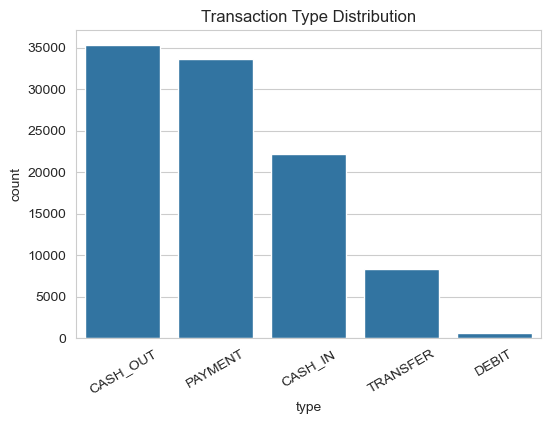

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(x='type', data=df, order=df['type'].value_counts().index)
plt.title("Transaction Type Distribution")
plt.xticks(rotation=30)
plt.show()


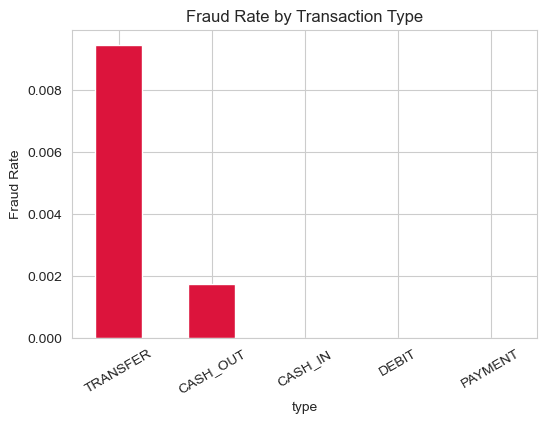

type
TRANSFER    0.009462
CASH_OUT    0.001755
CASH_IN     0.000000
DEBIT       0.000000
PAYMENT     0.000000
Name: isFraud, dtype: float64


In [ ]:
fraud_by_type = df.groupby('type')['isFraud'].mean().sort_values(ascending=False)
plt.figure(figsize=(6,4))
fraud_by_type.plot(kind='bar', color='crimson')
plt.title("Fraud Rate by Transaction Type")
plt.ylabel("Fraud Rate")
plt.xticks(rotation=30)
plt.show()
print(fraud_by_type)


## 4. Preprocessing & Feature Extraction

In [ ]:
# Encode Categorical Column (type) [convert text to numerical values]
le = LabelEncoder()
df['type_encoded'] = le.fit_transform(df['type'])
print(dict(zip(le.classes_, le.transform(le.classes_))))


{'CASH_IN': np.int64(0), 'CASH_OUT': np.int64(1), 'DEBIT': np.int64(2), 'PAYMENT': np.int64(3), 'TRANSFER': np.int64(4)}


In [ ]:
# Feature Extraction -- error-balance features flag accounting mismatches typical of
# fraudulent transfers (a legitimate transaction's balances should reconcile; laundering/fraud
# transactions frequently do not, since funds are being deliberately obscured or drained)
df['errorBalanceOrig'] = df['newbalanceOrig'] + df['amount'] - df['oldbalanceOrg']
df['errorBalanceDest'] = df['oldbalanceDest'] + df['amount'] - df['newbalanceDest']
df['origBecameZero'] = ((df['oldbalanceOrg'] > 0) & (df['newbalanceOrig'] == 0)).astype(int)
df['destWasZero'] = ((df['oldbalanceDest'] == 0) & (df['newbalanceDest'] == 0) & (df['amount'] > 0)).astype(int)
df['isHighRiskType'] = df['type'].isin(['TRANSFER', 'CASH_OUT']).astype(int)

large_amount_threshold = df['amount'].quantile(0.95)
df['isLargeTxn'] = (df['amount'] > large_amount_threshold).astype(int)

df.head()


,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud,type_encoded,errorBalanceOrig,errorBalanceDest,origBecameZero,destWasZero,isHighRiskType,isLargeTxn
0,278,CASH_IN,330218.42,C632336343,20866.00,351084.42,C834976624,452419.57,122201.15,0,0,0,660436.84,660436.84,0,0,0,0
1,15,PAYMENT,11647.08,C1264712553,30370.00,18722.92,M215391829,0.00,0.00,0,0,3,0.00,11647.08,0,1,0,0
2,10,CASH_IN,152264.21,C1746846248,106589.00,258853.21,C1607284477,201303.01,49038.80,0,0,0,304528.42,304528.42,0,0,0,0
3,403,TRANSFER,1551760.63,C333676753,0.00,0.00,C1564353608,3198359.45,4750120.08,0,0,4,1551760.63,0.00,0,0,1,1
4,206,CASH_IN,78172.30,C813403091,2921331.58,2999503.88,C1091768874,415821.90,337649.60,0,0,0,156344.60,156344.60,0,0,0,0


## 5. Transaction Monitoring -- Multi-Algorithm Fraud Classification

Predicting `isFraud` at the individual transaction level. Five algorithms are compared,
following the base paper's methodology of testing multiple model families (linear, tree-based,
ensemble, boosting, distance-based) before selecting the best performer for deployment.


In [ ]:
df_model = df.drop(columns=['nameOrig', 'nameDest', 'type', 'isFlaggedFraud'])

X = df_model.drop(columns=['isFraud'])
y = df_model['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training Samples:", len(X_train))
print("Testing Samples:", len(X_test))
print("Fraud cases -- train:", y_train.sum(), " test:", y_test.sum())


Training Samples: 80000
Testing Samples: 20000
Fraud cases -- train: 113  test: 28


In [ ]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Scaling Done")


Scaling Done


In [ ]:
# 5 algorithms compared: Logistic Regression, Decision Tree, Random Forest, KNN, XGBoost
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
    "XGBoost": XGBClassifier(n_estimators=200, max_depth=6, learning_rate=0.1, random_state=42,
                              eval_metric='logloss',
                              scale_pos_weight=(y_train==0).sum()/(y_train==1).sum())
}

scaled_models = {"Logistic Regression", "KNN"}  # distance/gradient-based models need scaled input

txn_results = []
txn_predictions = {}
for name, model in models.items():
    if name in scaled_models:
        model.fit(X_train_scaled, y_train)
        y_pred = model.predict(X_test_scaled)
        y_proba = model.predict_proba(X_test_scaled)[:, 1]
    else:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]

    txn_predictions[name] = (y_pred, y_proba)
    txn_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall": recall_score(y_test, y_pred, zero_division=0),
        "F1": f1_score(y_test, y_pred, zero_division=0),
        "AUROC": roc_auc_score(y_test, y_proba)
    })

txn_results_df = pd.DataFrame(txn_results).sort_values("AUROC", ascending=False).reset_index(drop=True)
txn_results_df


,Model,Accuracy,Precision,Recall,F1,AUROC
0,Random Forest,1.00000,1.000000,1.000000,1.000000,1.000000
1,XGBoost,1.00000,1.000000,1.000000,1.000000,1.000000
2,Decision Tree,0.99995,0.965517,1.000000,0.982456,0.999975
3,Logistic Regression,0.97635,0.055888,1.000000,0.105860,0.998512
4,KNN,0.99960,0.916667,0.785714,0.846154,0.892787


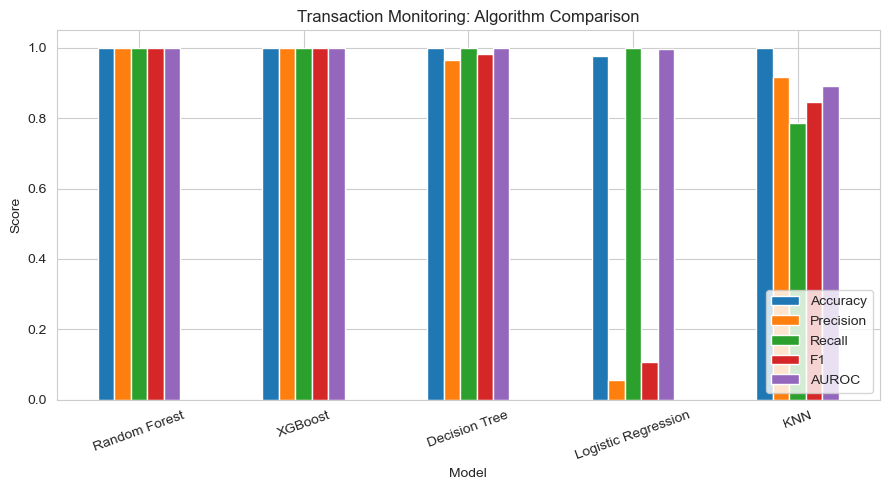

In [ ]:
# Visual comparison of all 5 algorithms
fig, ax = plt.subplots(figsize=(9,5))
txn_results_df.set_index("Model")[["Accuracy","Precision","Recall","F1","AUROC"]].plot(kind='bar', ax=ax)
plt.title("Transaction Monitoring: Algorithm Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()


Best Transaction Monitoring Model: Random Forest
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     19972
           1       1.00      1.00      1.00        28

    accuracy                           1.00     20000
   macro avg       1.00      1.00      1.00     20000
weighted avg       1.00      1.00      1.00     20000



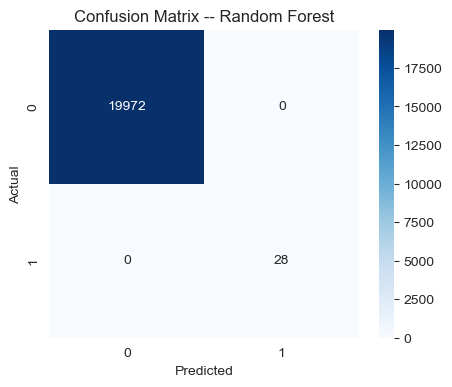

In [ ]:
# Confusion matrix for the best model (by AUROC)
best_txn_model_name = txn_results_df.iloc[0]["Model"]
y_pred_best, y_proba_best = txn_predictions[best_txn_model_name]

print("Best Transaction Monitoring Model:", best_txn_model_name)
print(classification_report(y_test, y_pred_best))

cm = confusion_matrix(y_test, y_pred_best)
plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix -- {best_txn_model_name}")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


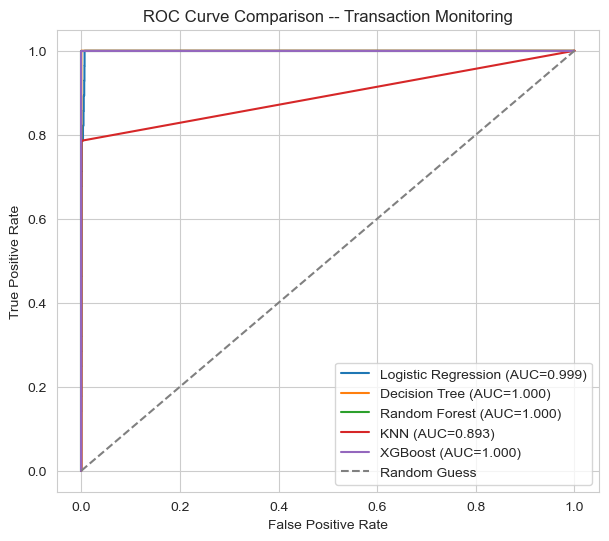

In [ ]:
# ROC Curve comparison across all 5 algorithms
plt.figure(figsize=(7,6))
for name, (y_pred, y_proba) in txn_predictions.items():
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    auc = roc_auc_score(y_test, y_proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")
plt.plot([0,1],[0,1], linestyle='--', color='gray', label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison -- Transaction Monitoring")
plt.legend()
plt.show()


 6. Client Risk Classification -- Aggregating Transactions per Client



In [ ]:
client_agg = df.groupby('nameOrig').agg(
    txn_count=('amount', 'count'),
    total_amount=('amount', 'sum'),
    avg_amount=('amount', 'mean'),
    max_amount=('amount', 'max'),
    fraud_count=('isFraud', 'sum'),
    became_zero_count=('origBecameZero', 'sum'),
    high_risk_type_count=('isHighRiskType', 'sum'),
    large_txn_count=('isLargeTxn', 'sum'),
    avg_error_balance=('errorBalanceOrig', lambda x: np.abs(x).mean()),
    unique_dest_count=('nameDest', 'nunique'),
).reset_index()

client_agg['high_risk_type_ratio'] = client_agg['high_risk_type_count'] / client_agg['txn_count']
client_agg['large_txn_ratio'] = client_agg['large_txn_count'] / client_agg['txn_count']
client_agg['became_zero_ratio'] = client_agg['became_zero_count'] / client_agg['txn_count']

print("Number of unique clients:", client_agg.shape[0])
client_agg.head()


Number of unique clients: 99999


,nameOrig,txn_count,total_amount,avg_amount,max_amount,fraud_count,became_zero_count,high_risk_type_count,large_txn_count,avg_error_balance,unique_dest_count,high_risk_type_ratio,large_txn_ratio,became_zero_ratio
0,C1000009135,1,3849.38,3849.38,3849.38,0,0,0,0,0.00,1,0.0,0.0,0.0
1,C1000015836,1,77027.49,77027.49,77027.49,0,1,1,0,57240.49,1,1.0,0.0,1.0
2,C1000018718,1,32100.16,32100.16,32100.16,0,0,0,0,0.00,1,0.0,0.0,0.0
3,C100006663,1,6941.84,6941.84,6941.84,0,0,0,0,6941.84,1,0.0,0.0,0.0
4,C1000071455,1,5968.81,5968.81,5968.81,0,1,0,0,5500.81,1,0.0,0.0,1.0


 Risk Tier Labeling (rule-based ground truth)




Risk tier distribution:
risk_tier
Low       79886
Medium    19972
High        141
Name: count, dtype: int64


C:\Users\SAHANA\AppData\Local\Temp\ipykernel_21880\1827190425.py:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='risk_tier', data=client_agg, order=['Low','Medium','High'],


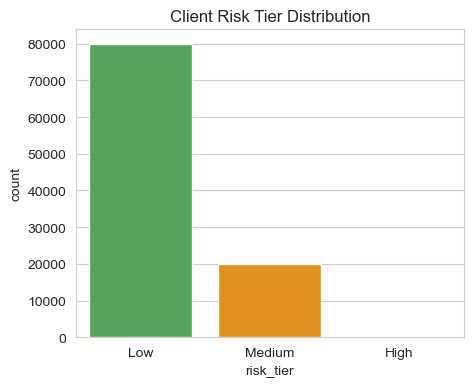

In [ ]:
behavior_cols = ['high_risk_type_ratio', 'large_txn_ratio', 'became_zero_ratio', 'avg_error_balance']
norm = client_agg[behavior_cols].copy()
for c in behavior_cols:
    norm[c] = (norm[c] - norm[c].min()) / (norm[c].max() - norm[c].min() + 1e-9)
client_agg['behavior_score'] = norm.mean(axis=1)

def assign_tier(row, medium_threshold):
    if row['fraud_count'] > 0:
        return 'High'
    elif row['behavior_score'] >= medium_threshold:
        return 'Medium'
    else:
        return 'Low'

medium_cutoff = client_agg.loc[client_agg['fraud_count'] == 0, 'behavior_score'].quantile(0.80)
client_agg['risk_tier'] = client_agg.apply(lambda r: assign_tier(r, medium_cutoff), axis=1)

print("Risk tier distribution:")
print(client_agg['risk_tier'].value_counts())

plt.figure(figsize=(5,4))
sns.countplot(x='risk_tier', data=client_agg, order=['Low','Medium','High'],
              palette={'Low':'#4CAF50','Medium':'#FF9800','High':'#F44336'})
plt.title("Client Risk Tier Distribution")
plt.show()


In [ ]:
feature_cols = ['txn_count', 'total_amount', 'avg_amount', 'max_amount',
                 'high_risk_type_ratio', 'large_txn_ratio', 'became_zero_ratio',
                 'avg_error_balance', 'unique_dest_count']

X_client = client_agg[feature_cols]
y_client = client_agg['risk_tier']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_client, y_client, test_size=0.25, random_state=42, stratify=y_client
)

scaler_c = StandardScaler()
Xc_train_scaled = scaler_c.fit_transform(Xc_train)
Xc_test_scaled = scaler_c.transform(Xc_test)

print("Client training samples:", len(Xc_train))
print("Client testing samples:", len(Xc_test))


Client training samples: 74999
Client testing samples: 25000


In [ ]:
client_models = {
    "Logistic Regression": LogisticRegression(max_iter=1000, random_state=42, class_weight='balanced'),
    "Decision Tree": DecisionTreeClassifier(max_depth=8, random_state=42, class_weight='balanced'),
    "Random Forest": RandomForestClassifier(n_estimators=200, max_depth=10, random_state=42, class_weight='balanced'),
    "KNN": KNeighborsClassifier(n_neighbors=5),
}

client_results = []
client_predictions = {}
for name, model in client_models.items():
    if name in ("Logistic Regression", "KNN"):
        model.fit(Xc_train_scaled, yc_train)
        y_pred = model.predict(Xc_test_scaled)
    else:
        model.fit(Xc_train, yc_train)
        y_pred = model.predict(Xc_test)

    client_predictions[name] = (model, y_pred)
    client_results.append({
        "Model": name,
        "Accuracy": accuracy_score(yc_test, y_pred),
        "Precision(macro)": precision_score(yc_test, y_pred, average='macro', zero_division=0),
        "Recall(macro)": recall_score(yc_test, y_pred, average='macro', zero_division=0),
        "F1(macro)": f1_score(yc_test, y_pred, average='macro', zero_division=0)
    })

client_results_df = pd.DataFrame(client_results).sort_values("F1(macro)", ascending=False).reset_index(drop=True)
client_results_df


,Model,Accuracy,Precision(macro),Recall(macro),F1(macro)
0,Decision Tree,1.00000,1.000000,1.000000,1.000000
1,Random Forest,1.00000,1.000000,1.000000,1.000000
2,KNN,0.99864,0.961646,0.894504,0.923705
3,Logistic Regression,0.97384,0.673595,0.932030,0.685741


Best Client Risk Classification Model: Decision Tree
              precision    recall  f1-score   support

        High       1.00      1.00      1.00        35
         Low       1.00      1.00      1.00     19972
      Medium       1.00      1.00      1.00      4993

    accuracy                           1.00     25000
   macro avg       1.00      1.00      1.00     25000
weighted avg       1.00      1.00      1.00     25000



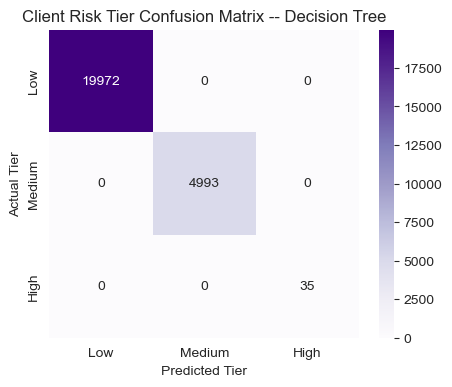

In [ ]:
best_client_model_name = client_results_df.iloc[0]["Model"]
best_client_model, y_pred_client_best = client_predictions[best_client_model_name]

print("Best Client Risk Classification Model:", best_client_model_name)
print(classification_report(yc_test, y_pred_client_best))

cm_client = confusion_matrix(yc_test, y_pred_client_best, labels=['Low','Medium','High'])
plt.figure(figsize=(5,4))
sns.heatmap(cm_client, annot=True, fmt='d', cmap='Purples',
            xticklabels=['Low','Medium','High'], yticklabels=['Low','Medium','High'])
plt.title(f"Client Risk Tier Confusion Matrix -- {best_client_model_name}")
plt.xlabel("Predicted Tier")
plt.ylabel("Actual Tier")
plt.show()


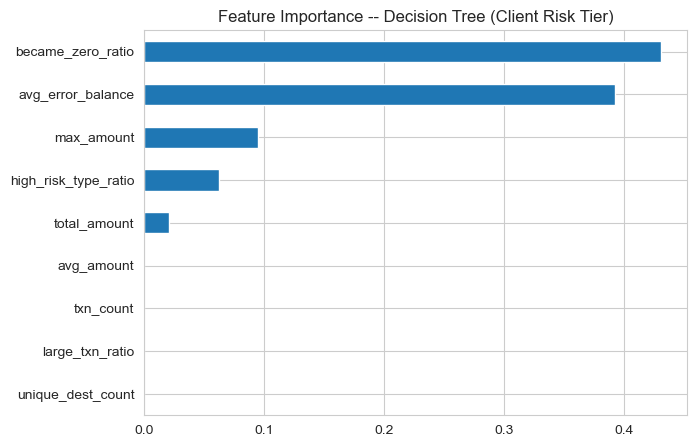

became_zero_ratio       4.303929e-01
avg_error_balance       3.919075e-01
max_amount              9.466567e-02
high_risk_type_ratio    6.217356e-02
total_amount            2.086043e-02
avg_amount              9.136394e-15
txn_count               0.000000e+00
large_txn_ratio         0.000000e+00
unique_dest_count       0.000000e+00
dtype: float64


In [ ]:
# Feature importance for the client risk model (explainability -- which transaction
# behaviors actually drive a client being flagged higher risk)
if hasattr(best_client_model, 'feature_importances_'):
    importances = pd.Series(best_client_model.feature_importances_, index=feature_cols).sort_values(ascending=False)
    plt.figure(figsize=(7,5))
    importances.plot(kind='barh')
    plt.title(f"Feature Importance -- {best_client_model_name} (Client Risk Tier)")
    plt.gca().invert_yaxis()
    plt.show()
    print(importances)


## 7. Export Data for Dashboard

In [ ]:
# Save the client risk table and a sample of transaction-level predictions.
# These feed the interactive HTML dashboard (separate file).
client_agg_export = client_agg.copy()
client_agg_export['predicted_tier'] = best_client_model.predict(
    scaler_c.transform(client_agg[feature_cols]) if best_client_model_name in ("Logistic Regression","KNN")
    else client_agg[feature_cols]
)
client_agg_export.to_csv("client_risk_table.csv", index=False)

txn_sample = df.sample(n=min(500, len(df)), random_state=1)[
    ['step','type','amount','nameOrig','nameDest','isFraud','isHighRiskType','origBecameZero']
]
txn_sample.to_csv("transaction_sample.csv", index=False)

txn_results_df.to_csv("txn_model_comparison.csv", index=False)
client_results_df.to_csv("client_model_comparison.csv", index=False)

print("Dashboard data exported: client_risk_table.csv, transaction_sample.csv, model comparison tables")


Dashboard data exported: client_risk_table.csv, transaction_sample.csv, model comparison tables
